# TCGA-PAAD data preparation checks

This notebook uses the processed open-access GDC STAR-Counts data. The normalized matrix is `log2(counts + 1)` transformed counts, not TPM.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROCESSED = ROOT / 'data' / 'processed'
FIGURES = ROOT / 'results' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

PANEL = ['CD8A', 'CD8B', 'IFNG', 'GZMB', 'PRF1', 'NKG7', 'CXCL9', 'CXCL10', 'CXCL11', 'STAT1', 'IRF1', 'HLA-A', 'HLA-B', 'HLA-C', 'B2M', 'TGFB1', 'CXCL12', 'POSTN', 'HIF1A', 'VEGFA', 'KDR', 'FAP', 'COL1A1', 'CD163', 'CSF1R', 'FOXP3', 'IL10']
counts = pd.read_csv(PROCESSED / 'PAAD_27gene_raw_counts.csv', index_col='gene_symbol')
expression = pd.read_csv(PROCESSED / 'PAAD_27gene_log2_counts.csv', index_col='gene_symbol')
metadata = pd.read_csv(PROCESSED / 'PAAD_sample_metadata.csv')
print(f'Raw matrix: {counts.shape[0]} genes x {counts.shape[1]} samples')
print(f'Log2 matrix: {expression.shape[0]} genes x {expression.shape[1]} samples')
print(f'Metadata: {metadata.shape[0]} samples x {metadata.shape[1]} fields')

Raw matrix: 27 genes x 178 samples
Log2 matrix: 27 genes x 178 samples
Metadata: 178 samples x 9 fields


In [2]:
display(expression.head())
missing_panel = sorted(set(PANEL) - set(expression.index))
print('Panel genes found:', len(PANEL) - len(missing_panel))
print('Panel genes missing:', missing_panel if missing_panel else 'None')
print('Unique gene symbols:', expression.index.is_unique)
print('Unique sample IDs:', expression.columns.is_unique)
print('Matrix and metadata sample IDs agree:', set(expression.columns) == set(metadata['sample_id']))
print('Missing matrix values:', int(expression.isna().sum().sum()))
zero_heavy = (counts.eq(0).mean(axis=1).sort_values(ascending=False) * 100).rename('zero_percent')
display(zero_heavy.to_frame())

,TCGA-IB-7888-01A,TCGA-FB-A78T-01A,TCGA-2J-AABI-01A,TCGA-HZ-7918-01A,TCGA-2J-AABO-01A,TCGA-IB-AAUN-01A,TCGA-HZ-7924-01A,TCGA-3A-A9I7-01A,TCGA-FB-AAPY-01A,TCGA-RB-A7B8-01A,...,TCGA-IB-7889-01A,TCGA-FB-A5VM-01A,TCGA-F2-A44H-01A,TCGA-IB-7890-01A,TCGA-HZ-A77P-01A,TCGA-FB-AAQ0-01A,TCGA-Z5-AAPL-01A,TCGA-2J-AAB6-01A,TCGA-LB-A8F3-01A,TCGA-IB-A5SO-01A
gene_symbol,,,,,,,,,,,,,,,,,,,,,
CD8A,9.447083,8.335390,7.562242,11.092096,7.882643,8.483816,9.550747,9.605480,9.436712,8.829723,...,10.109831,9.214319,6.569856,6.845490,9.554589,5.392317,11.377753,6.426265,6.209453,9.994353
CD8B,7.392317,6.375039,5.754888,8.710806,6.189825,6.339850,7.607330,7.813781,7.400879,6.539159,...,8.066089,8.417853,4.000000,3.459432,7.247928,2.807355,9.581201,4.459432,4.247928,7.942515
IFNG,3.584963,1.584963,3.321928,5.554589,1.000000,3.459432,2.321928,3.169925,2.000000,2.807355,...,4.392317,2.584963,1.584963,1.000000,2.321928,0.000000,5.129283,1.584963,0.000000,3.321928
GZMB,7.960002,7.011227,8.503826,9.231221,5.832890,8.455327,7.707359,6.357552,6.475733,6.882643,...,7.546894,8.379378,3.906891,4.954196,7.129283,4.754888,10.182394,5.209453,5.614710,6.832890
PRF1,8.906891,7.839204,8.577429,9.914385,6.442943,8.199672,9.581201,8.813781,8.731319,8.451211,...,9.063395,8.787903,6.285402,7.266787,8.980140,6.807355,9.878051,6.569856,6.409391,9.640245


Panel genes found: 27
Panel genes missing: None
Unique gene symbols: True
Unique sample IDs: True
Matrix and metadata sample IDs agree: True
Missing matrix values: 0


,zero_percent
gene_symbol,
IFNG,14.606742
FAP,0.561798
IL10,0.561798
GZMB,0.000000
PRF1,0.000000
NKG7,0.000000
CXCL9,0.000000
CXCL10,0.000000
CXCL11,0.000000


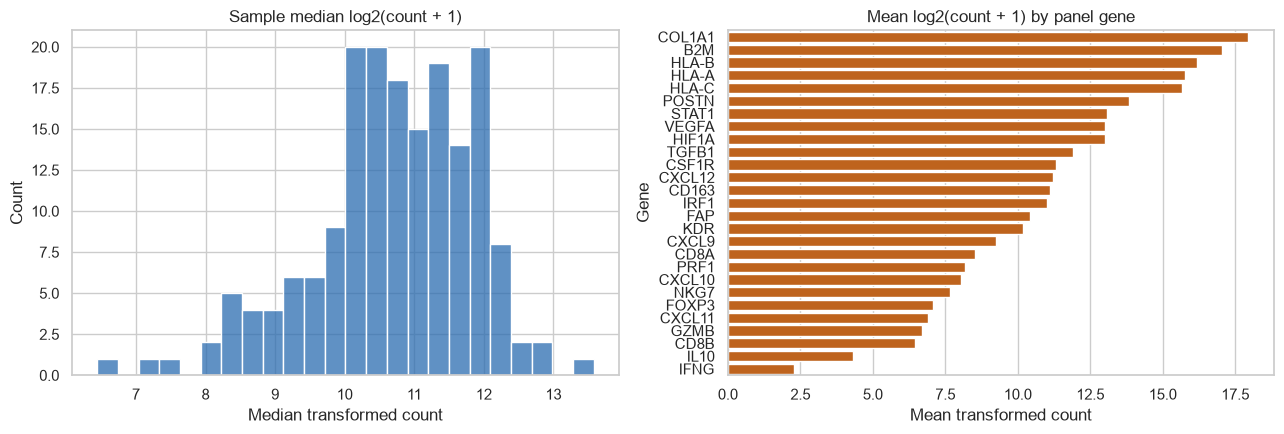

In [3]:
sns.set_theme(style='whitegrid', context='notebook')
sample_medians = expression.median(axis=0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(sample_medians, bins=24, ax=axes[0], color='#2b6cb0')
axes[0].set(title='Sample median log2(count + 1)', xlabel='Median transformed count')
gene_means = expression.mean(axis=1).sort_values(ascending=False)
sns.barplot(x=gene_means.values, y=gene_means.index, ax=axes[1], color='#d95f02')
axes[1].set(title='Mean log2(count + 1) by panel gene', xlabel='Mean transformed count', ylabel='Gene')
fig.tight_layout()
fig.savefig(FIGURES / 'PAAD_27gene_expression_distributions.png', dpi=200, bbox_inches='tight')
plt.show()